In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [109]:
from pathlib import Path

p = Path(r"C:\Users\borde\OneDrive\Desktop\fork\week0\data\Netflix\netflix1.csv")
print(p.exists())
print(p.resolve())

True
C:\Users\borde\OneDrive\Desktop\fork\week0\data\Netflix\netflix1.csv


In [110]:
df = pd.read_csv(r"C:\Users\borde\OneDrive\Desktop\fork\week0\data\Netflix\netflix1.csv", parse_dates=["date_added"])

In [111]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## Plan
<br>
columns to one hot code rating, type, listed_in maybe country
<br>
or convert countries to geographic regions
<br>
split duration to episode_duration and run_period
<br>
split date_added to month, year; drop day
<br>
scale release_year


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   country       8790 non-null   str           
 5   date_added    8790 non-null   datetime64[us]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   str           
 8   duration      8790 non-null   str           
 9   listed_in     8790 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.8 KB


In [113]:
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


In [114]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [115]:
df.duplicated().sum()

np.int64(0)

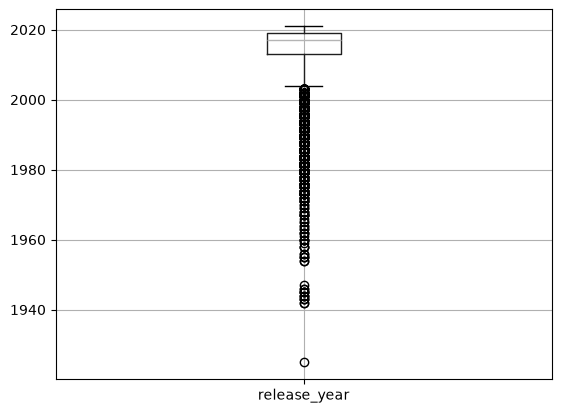

In [116]:
#fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="release_year")
plt.show()

In [117]:
def iqr_bounds(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lower, upper = iqr_bounds(df["release_year"])
print(f"Release Year: normal range is {lower:.2f} to {upper:.2f}")

release_outliers = df[(df["release_year"] < lower) | (df["release_year"] > upper)]
print("Number of Release outliers:", len(release_outliers))
release_outliers[["type", "title", "country","release_year"]].sort_values("release_year", ascending=False).head()



Release Year: normal range is 2004.00 to 2028.00
Number of Release outliers: 717


,type,title,country,release_year
4999,Movie,Gothika,United States,2003
224,Movie,My Boss's Daughter,United States,2003
219,Movie,Love Don't Cost a Thing,United States,2003
312,TV Show,Westside Story,Pakistan,2003
5158,Movie,Inuyasha the Movie - La spada del dominatore d...,Japan,2003


In [118]:
clean = df.copy()

In [119]:
print("Mean Release Year:  ", round(df["release_year"].mean()))
print("Median age: ", clean["release_year"].median())

Mean Release Year:   2014
Median age:  2017.0


In [120]:
print('unique types', df['type'].unique().tolist())
print('unique countries', len(df['country'].unique().tolist()), df['country'].unique().tolist())
print('unique ratings', df['rating'].unique().tolist())
print('unique listed_in', len(df['listed_in'].unique().tolist()), df['listed_in'].unique().tolist())

unique types ['Movie', 'TV Show']
unique countries 86 ['United States', 'France', 'Brazil', 'United Kingdom', 'India', 'Germany', 'Pakistan', 'Not Given', 'China', 'South Africa', 'Japan', 'Nigeria', 'Spain', 'Philippines', 'Australia', 'Argentina', 'Canada', 'Hong Kong', 'Italy', 'New Zealand', 'Egypt', 'Colombia', 'Mexico', 'Belgium', 'Switzerland', 'Taiwan', 'Bulgaria', 'Poland', 'South Korea', 'Saudi Arabia', 'Thailand', 'Indonesia', 'Kuwait', 'Malaysia', 'Vietnam', 'Lebanon', 'Romania', 'Syria', 'United Arab Emirates', 'Sweden', 'Mauritius', 'Austria', 'Turkey', 'Czech Republic', 'Cameroon', 'Netherlands', 'Ireland', 'Russia', 'Kenya', 'Chile', 'Uruguay', 'Bangladesh', 'Portugal', 'Hungary', 'Norway', 'Singapore', 'Iceland', 'Serbia', 'Namibia', 'Peru', 'Mozambique', 'Ghana', 'Zimbabwe', 'Israel', 'Finland', 'Denmark', 'Paraguay', 'Cambodia', 'Georgia', 'Soviet Union', 'Greece', 'West Germany', 'Iran', 'Venezuela', 'Slovenia', 'Guatemala', 'Jamaica', 'Somalia', 'Croatia', 'Jordan'

In [121]:
print('unique types', df['type'].unique().tolist())
print('unique countries', len(df['country'].unique().tolist()), df['country'].unique().tolist())
print('unique ratings', df['rating'].unique().tolist())

unique types ['Movie', 'TV Show']
unique countries 86 ['United States', 'France', 'Brazil', 'United Kingdom', 'India', 'Germany', 'Pakistan', 'Not Given', 'China', 'South Africa', 'Japan', 'Nigeria', 'Spain', 'Philippines', 'Australia', 'Argentina', 'Canada', 'Hong Kong', 'Italy', 'New Zealand', 'Egypt', 'Colombia', 'Mexico', 'Belgium', 'Switzerland', 'Taiwan', 'Bulgaria', 'Poland', 'South Korea', 'Saudi Arabia', 'Thailand', 'Indonesia', 'Kuwait', 'Malaysia', 'Vietnam', 'Lebanon', 'Romania', 'Syria', 'United Arab Emirates', 'Sweden', 'Mauritius', 'Austria', 'Turkey', 'Czech Republic', 'Cameroon', 'Netherlands', 'Ireland', 'Russia', 'Kenya', 'Chile', 'Uruguay', 'Bangladesh', 'Portugal', 'Hungary', 'Norway', 'Singapore', 'Iceland', 'Serbia', 'Namibia', 'Peru', 'Mozambique', 'Ghana', 'Zimbabwe', 'Israel', 'Finland', 'Denmark', 'Paraguay', 'Cambodia', 'Georgia', 'Soviet Union', 'Greece', 'West Germany', 'Iran', 'Venezuela', 'Slovenia', 'Guatemala', 'Jamaica', 'Somalia', 'Croatia', 'Jordan'

In [122]:
clean["type_encoded"] = clean["type"].map({"Movie": 0, "TV Show": 1})
clean[["type", "type_encoded"]].head()

,type,type_encoded
0,Movie,0
1,TV Show,1
2,TV Show,1
3,Movie,0
4,Movie,0


In [123]:
before = len(clean)
clean = clean[clean["country"] != "Not Given"]
after = len(clean)
print(before, after)

8790 8503


In [124]:
rating_dummies = pd.get_dummies(clean["rating"], prefix="rating", dtype=int)

pd.concat([clean["rating"], rating_dummies], axis=1).head()

,rating,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR
0,PG-13,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,TV-MA,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,TV-MA,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,TV-PG,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,TV-MA,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [125]:
import pycountry_convert as pc

SPECIAL_COUNTRIES = {
    "Soviet Union": "Europe",  # choose the continent you want
    "USSR": "Europe",
    "West Germany": "Europe"
}

def country_to_continent(country):
    if pd.isna(country) or country =="Not Given":
        return None

    if country in SPECIAL_COUNTRIES.keys():
        return SPECIAL_COUNTRIES[country]
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        return pc.convert_continent_code_to_continent_name(continent_code)
    except Exception:
        return None

#countries = list(clean['country'])
# [country_to_continent(country) for country in countries]

clean["continent"] = clean["country"].apply(country_to_continent)




In [ ]:
# check if there are any countries not converted to continent
clean.loc[clean["continent"].isna(), "country"]
#clean.loc[clean["continent"].isna(), "country"].unique

Series([], Name: country, dtype: str)

In [127]:
continent_dummies = pd.get_dummies(clean["continent"], prefix="continent", dtype=int)

pd.concat([clean["continent"], continent_dummies], axis=1).head()

,continent,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,North America,0,0,0,1,0,0
1,Europe,0,0,1,0,0,0
2,North America,0,0,0,1,0,0
3,South America,0,0,0,0,0,1
4,North America,0,0,0,1,0,0


In [134]:
if not pd.api.types.is_datetime64_any_dtype(clean["date_added"]):
    clean["date_added"] = pd.to_datetime(clean["date_added"])
clean["day"] = clean["date_added"].dt.day
clean["month"] = clean["date_added"].dt.month
clean["year"] = clean["date_added"].dt.year

clean.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,type_encoded,continent,day,month,year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,0,North America,25,9,2021
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Europe,24,9,2021
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,North America,24,9,2021
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",0,South America,22,9,2021
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",0,North America,24,9,2021
